# Biểu đồ kết quả huấn luyện và đánh giá cho đồ án

Notebook sử dụng lịch sử huấn luyện và kết quả kiểm thử trong các log đã lưu.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path.cwd().resolve()
if not (ROOT / 'checkpoints' / 'runs').exists():
    candidates = [p for p in [ROOT, *ROOT.parents] if (p / 'checkpoints' / 'runs').exists()]
    if not candidates:
        raise FileNotFoundError('Không tìm thấy thư mục checkpoints/runs')
    ROOT = candidates[0]
RUNS = ROOT / 'checkpoints' / 'runs'
OUT = ROOT / 'notebooks' / 'model_evaluation'
OUT.mkdir(parents=True, exist_ok=True)

def load_json(path):
    with Path(path).open(encoding='utf-8') as handle:
        return json.load(handle)

all_models = load_json(RUNS / 'train_all_4class_gpu_final' / 'train_all_summary.json')
product = load_json(RUNS / 'product_4class_fixed_triple_xgb' / 'summary.json')
component_paths = {
    'Final XGB': RUNS / 'product_4class_fixed_triple_xgb' / 'final_xgb' / 'summary.json',
    'Boost XGB': RUNS / 'product_4class_fixed_triple_xgb' / 'boost_xgb' / 'summary.json',
    'Targeted XGB': RUNS / 'product_4class_fixed_triple_xgb' / 'targeted_xgb' / 'summary.json',
}
components = {name: load_json(path) for name, path in component_paths.items()}

sns.set_theme(style='whitegrid', context='paper', font_scale=1.15)
plt.rcParams.update({'figure.dpi': 120, 'savefig.dpi': 300, 'font.family': 'DejaVu Sans'})
COLORS = ['#173F5F', '#D95D39', '#2A9D8F', '#E9C46A', '#6D597A']
CLASS_NAMES = ['Rất thấp', 'Thấp', 'Trung bình', 'Cao']
MODEL_LABELS = {
    'gru': 'GRU', 'gru_basic': 'GRU cơ bản', 'xgboost': 'XGBoost',
    'tcn': 'TCN', 'tiny_transformer': 'Tiny Transformer', 'bilstm': 'BiLSTM',
    'stgcn': 'ST-GCN', 'cnn_gru_fusion': 'CNN-GRU', 'hybrid': 'Hybrid',
    'residual_bigru_attn': 'BiGRU-Attention',
}
print(f'Đọc dữ liệu từ: {RUNS}')
print(f'Xuất hình tới: {OUT}')

Đọc dữ liệu từ: /home/bear/Documents/Workspace/Thesis20252/engagement-cpu/checkpoints/runs
Xuất hình tới: /home/bear/Documents/Workspace/Thesis20252/engagement-cpu/notebooks/model_evaluation


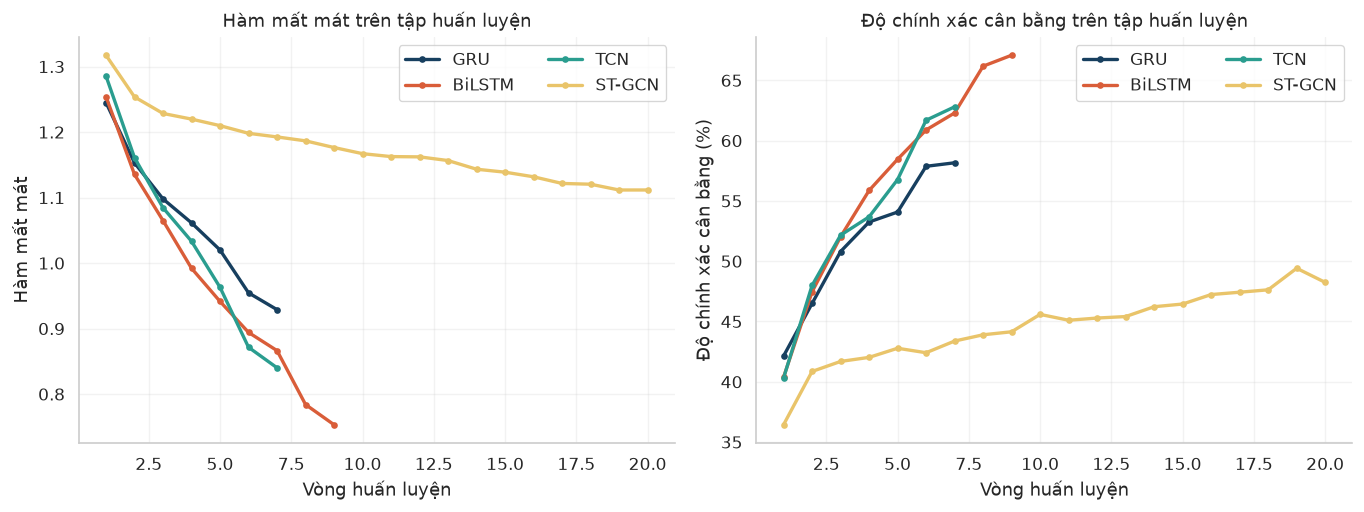

In [2]:
# 1. Diễn biến huấn luyện: chỉ sử dụng các khóa train_*
selected = ['gru', 'bilstm', 'tcn', 'stgcn']
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.4))
for idx, name in enumerate(selected):
    item = next(x for x in all_models['items'] if x['model_name'] == name)
    history = item.get('train_history', [])
    epochs = [row['epoch'] for row in history]
    axes[0].plot(epochs, [row['train_loss'] for row in history], marker='o', ms=3, lw=2, label=MODEL_LABELS[name], color=COLORS[idx])
    axes[1].plot(epochs, [100 * row['train_balanced_accuracy'] for row in history], marker='o', ms=3, lw=2, label=MODEL_LABELS[name], color=COLORS[idx])
axes[0].set(title='Hàm mất mát trên tập huấn luyện', xlabel='Vòng huấn luyện', ylabel='Hàm mất mát')
axes[1].set(title='Độ chính xác cân bằng trên tập huấn luyện', xlabel='Vòng huấn luyện', ylabel='Độ chính xác cân bằng (%)')
for ax in axes:
    ax.legend(frameon=True, ncol=2)
    ax.grid(alpha=0.25)
sns.despine()
fig.tight_layout()
fig.savefig(OUT / '01_dien_bien_huan_luyen.png', bbox_inches='tight', facecolor='white')
plt.show()

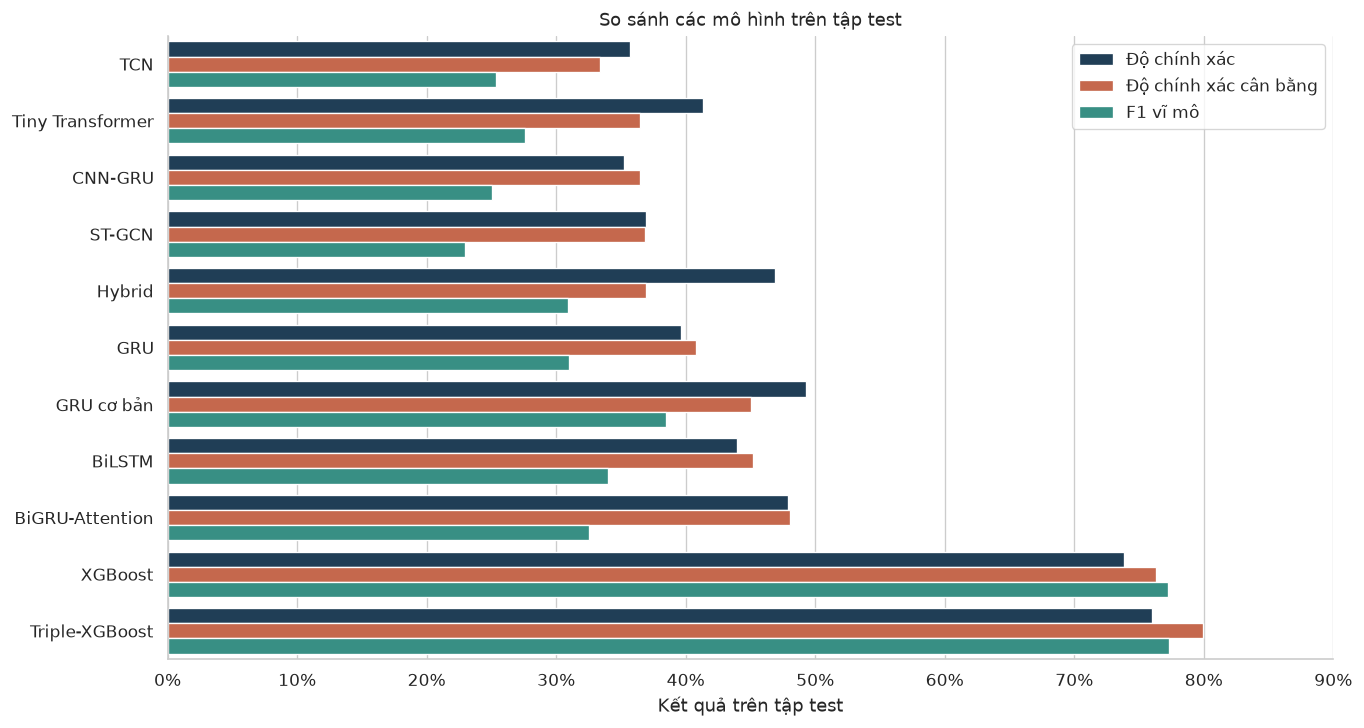

In [3]:
# 2. So sánh kết quả test giữa các mô hình
rows = []
for item in all_models['items']:
    metrics = item.get('test_video_metrics')
    if metrics:
        rows.append({'Mô hình': MODEL_LABELS.get(item['model_name'], item['model_name']), 'Độ chính xác': metrics['accuracy'], 'Độ chính xác cân bằng': metrics['balanced_accuracy'], 'F1 vĩ mô': metrics['f1_macro']})
rows.append({'Mô hình': 'Triple-XGBoost', 'Độ chính xác': product['test_metrics']['accuracy'], 'Độ chính xác cân bằng': product['test_metrics']['balanced_accuracy'], 'F1 vĩ mô': product['test_metrics']['f1_macro']})
comparison = pd.DataFrame(rows).sort_values('Độ chính xác cân bằng')
long = comparison.melt(id_vars='Mô hình', var_name='Chỉ số', value_name='Giá trị')
fig, ax = plt.subplots(figsize=(11.5, 6.2))
sns.barplot(data=long, y='Mô hình', x='Giá trị', hue='Chỉ số', palette=COLORS[:3], ax=ax)
ax.set(xlabel='Kết quả trên tập test', ylabel='', xlim=(0, 0.9), title='So sánh các mô hình trên tập test')
ax.xaxis.set_major_formatter(lambda x, pos: f'{x*100:.0f}%')
ax.legend(title='')
sns.despine()
fig.tight_layout()
fig.savefig(OUT / '02_so_sanh_mo_hinh_test.png', bbox_inches='tight', facecolor='white')
plt.show()

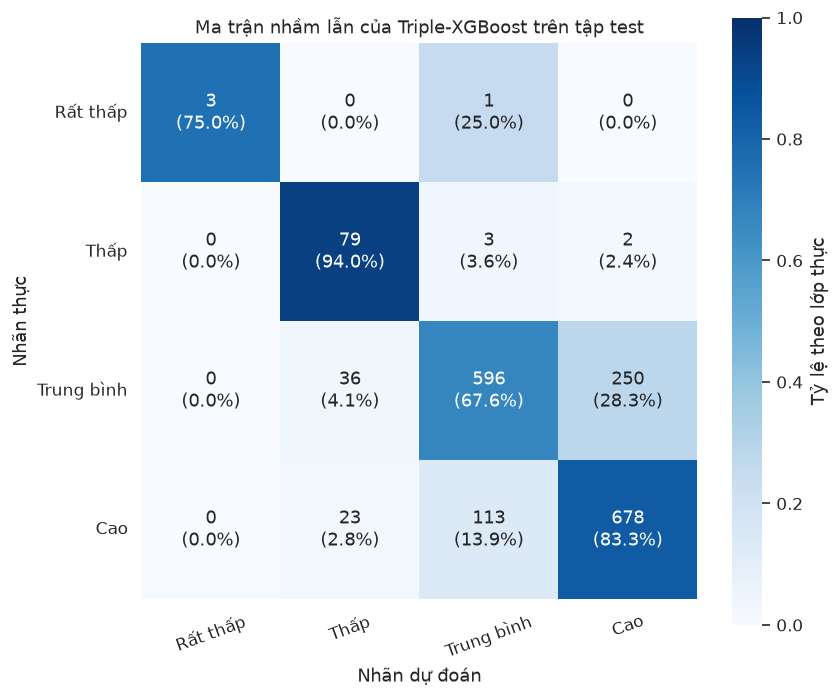

In [4]:
# 3. Ma trận nhầm lẫn của Triple-XGBoost trên tập test
cm = np.asarray(product['test_metrics']['confusion_matrix'], dtype=float)
cm_norm = cm / cm.sum(axis=1, keepdims=True)
annotations = np.empty_like(cm_norm, dtype=object)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        annotations[i, j] = f'{int(cm[i,j])}\n({cm_norm[i,j]*100:.1f}%)'
fig, ax = plt.subplots(figsize=(7.2, 6.1))
sns.heatmap(cm_norm, annot=annotations, fmt='', cmap='Blues', vmin=0, vmax=1, square=True, cbar_kws={'label': 'Tỷ lệ theo lớp thực'}, ax=ax)
ax.set(xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, xlabel='Nhãn dự đoán', ylabel='Nhãn thực', title='Ma trận nhầm lẫn của Triple-XGBoost trên tập test')
ax.tick_params(axis='x', rotation=20)
ax.tick_params(axis='y', rotation=0)
fig.tight_layout()
fig.savefig(OUT / '03_ma_tran_nham_lan_triple_xgb_test.png', bbox_inches='tight', facecolor='white')
plt.show()

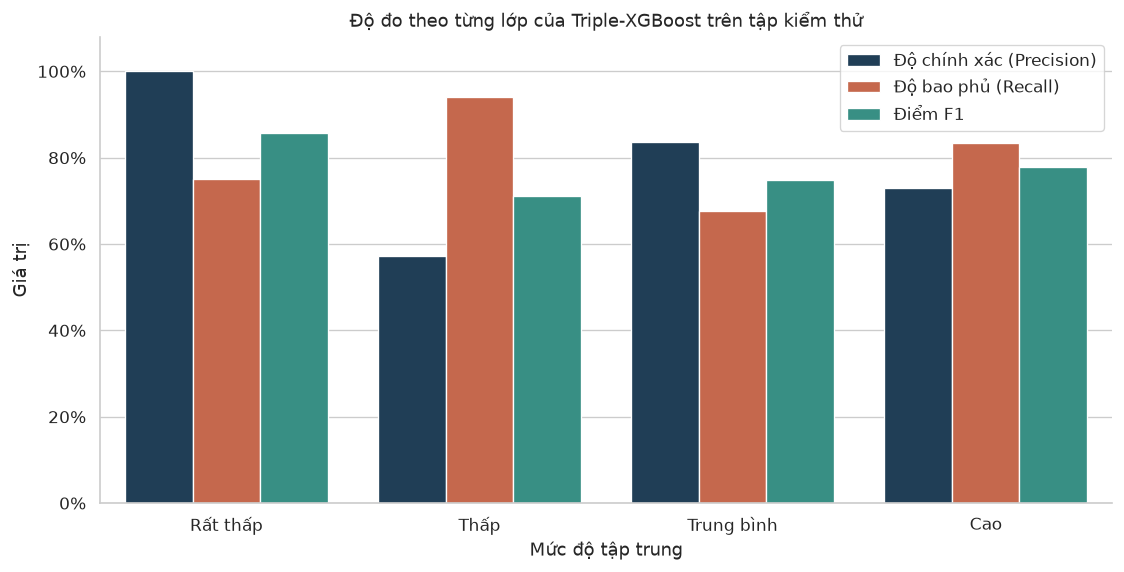

In [5]:
# 4. Precision, Recall và F1 theo lớp trên tập test
metrics = product['test_metrics']
per_class = pd.DataFrame({
    'Lớp': CLASS_NAMES,
    'Độ chính xác (Precision)': metrics['precision_per_class'],
    'Độ bao phủ (Recall)': metrics['recall_per_class'],
    'Điểm F1': metrics['f1_per_class'],
}).melt(id_vars='Lớp', var_name='Chỉ số', value_name='Giá trị')
fig, ax = plt.subplots(figsize=(9.5, 4.9))
sns.barplot(data=per_class, x='Lớp', y='Giá trị', hue='Chỉ số', palette=COLORS[:3], ax=ax)
ax.set(xlabel='Mức độ tập trung', ylabel='Giá trị', ylim=(0, 1.08), title='Độ đo theo từng lớp của Triple-XGBoost trên tập kiểm thử')
ax.yaxis.set_major_formatter(lambda y, pos: f'{y*100:.0f}%')
ax.legend(title='')
sns.despine()
fig.tight_layout()
fig.savefig(OUT / '04_do_do_theo_lop_triple_xgb_test.png', bbox_inches='tight', facecolor='white')
plt.show()

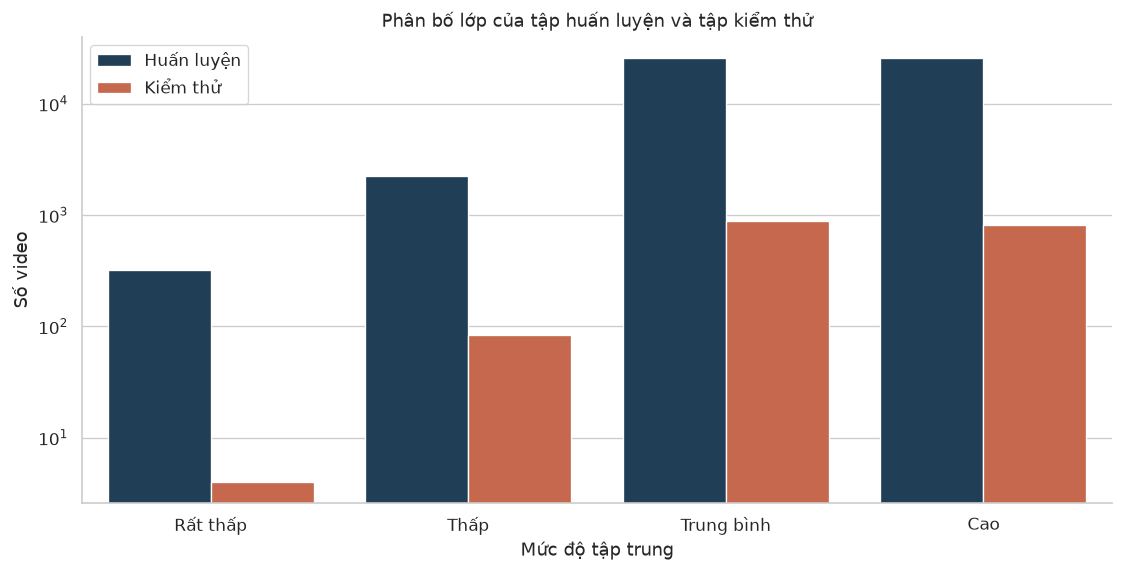

In [6]:
# 5. Phân bố lớp trên tập huấn luyện và tập kiểm thử
base_xgb = next(x for x in all_models['items'] if x['model_name'] == 'xgboost')
distribution = pd.DataFrame({
    'Lớp': CLASS_NAMES * 2,
    'Tập dữ liệu': ['Huấn luyện'] * 4 + ['Kiểm thử'] * 4,
    'Số mẫu': list(base_xgb['train_counts']) + list(product['test_metrics']['support_per_class']),
})
fig, ax = plt.subplots(figsize=(9.5, 4.9))
sns.barplot(data=distribution, x='Lớp', y='Số mẫu', hue='Tập dữ liệu', palette=[COLORS[0], COLORS[1]], ax=ax)
ax.set(xlabel='Mức độ tập trung', ylabel='Số video', title='Phân bố lớp của tập huấn luyện và tập kiểm thử')
ax.set_yscale('log')
ax.legend(title='')
sns.despine()
fig.tight_layout()
fig.savefig(OUT / '05_phan_bo_lop_train_test.png', bbox_inches='tight', facecolor='white')
plt.show()

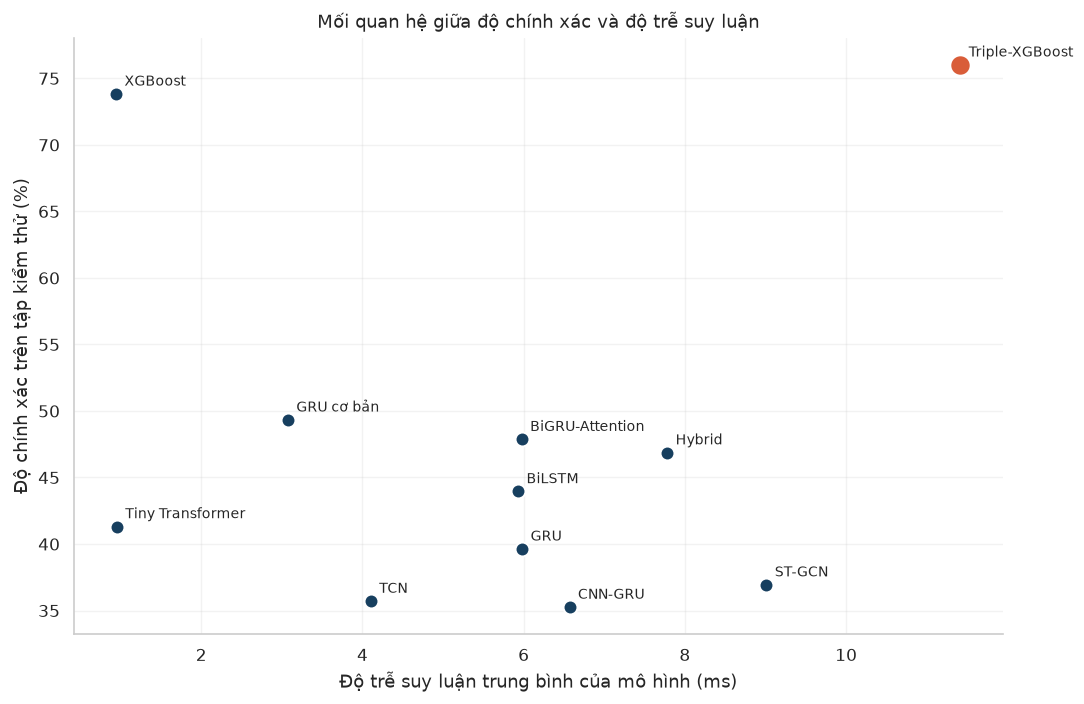

In [7]:
# 6. Trade-off giữa Accuracy test và model-side latency
trade_rows = []
for item in all_models['items']:
    test = item.get('test_video_metrics')
    latency = (item.get('latency') or {}).get('model_side', {}).get('latency_ms_mean')
    if test and latency is not None:
        trade_rows.append({'Mô hình': MODEL_LABELS.get(item['model_name'], item['model_name']), 'Độ chính xác': 100 * test['accuracy'], 'Độ trễ': latency, 'Đề xuất': False})
trade_rows.append({'Mô hình': 'Triple-XGBoost', 'Độ chính xác': 100 * product['test_metrics']['accuracy'], 'Độ trễ': product['latency']['model_side']['latency_ms_mean'], 'Đề xuất': True})
trade = pd.DataFrame(trade_rows)
fig, ax = plt.subplots(figsize=(9.2, 6.0))
for _, row in trade.iterrows():
    color = COLORS[1] if row['Đề xuất'] else COLORS[0]
    size = 150 if row['Đề xuất'] else 70
    ax.scatter(row['Độ trễ'], row['Độ chính xác'], s=size, color=color, edgecolor='white', linewidth=1.2, zorder=3)
    ax.annotate(row['Mô hình'], (row['Độ trễ'], row['Độ chính xác']), xytext=(5, 5), textcoords='offset points', fontsize=8.5)
ax.set(xlabel='Độ trễ suy luận trung bình của mô hình (ms)', ylabel='Độ chính xác trên tập kiểm thử (%)', title='Mối quan hệ giữa độ chính xác và độ trễ suy luận')
ax.grid(alpha=0.25)
sns.despine()
fig.tight_layout()
fig.savefig(OUT / '06_tradeoff_accuracy_latency.png', bbox_inches='tight', facecolor='white')
plt.show()

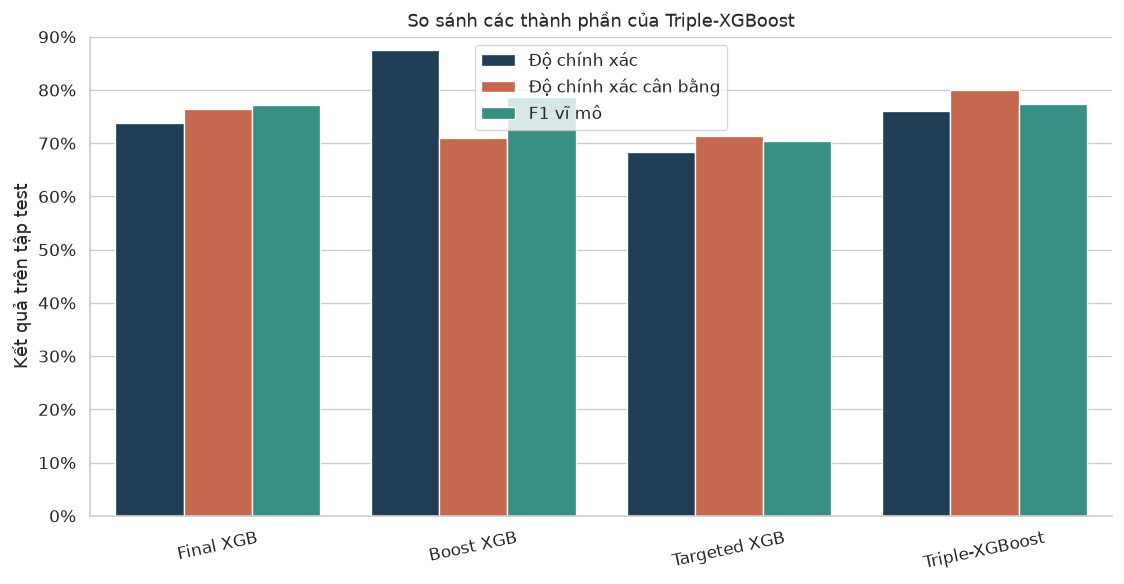

Đã tạo 7 hình:
- notebooks/model_evaluation/01_dien_bien_huan_luyen.png
- notebooks/model_evaluation/02_so_sanh_mo_hinh_test.png
- notebooks/model_evaluation/03_ma_tran_nham_lan_triple_xgb_test.png
- notebooks/model_evaluation/04_do_do_theo_lop_triple_xgb_test.png
- notebooks/model_evaluation/05_phan_bo_lop_train_test.png
- notebooks/model_evaluation/06_tradeoff_accuracy_latency.png
- notebooks/model_evaluation/07_so_sanh_thanh_phan_triple_xgb.png


In [8]:
# 7. So sánh ba thành phần với kết quả hợp nhất Triple-XGBoost
component_rows = []
for name, summary in components.items():
    test = summary['test_video_metrics'] if 'test_video_metrics' in summary else summary['test_metrics']
    component_rows.append({'Mô hình': name, 'Độ chính xác': test['accuracy'], 'Độ chính xác cân bằng': test['balanced_accuracy'], 'F1 vĩ mô': test['f1_macro']})
component_rows.append({'Mô hình': 'Triple-XGBoost', 'Độ chính xác': product['test_metrics']['accuracy'], 'Độ chính xác cân bằng': product['test_metrics']['balanced_accuracy'], 'F1 vĩ mô': product['test_metrics']['f1_macro']})
component_df = pd.DataFrame(component_rows).melt(id_vars='Mô hình', var_name='Chỉ số', value_name='Giá trị')
fig, ax = plt.subplots(figsize=(9.5, 5.0))
sns.barplot(data=component_df, x='Mô hình', y='Giá trị', hue='Chỉ số', palette=COLORS[:3], ax=ax)
ax.set(xlabel='', ylabel='Kết quả trên tập test', ylim=(0, 0.9), title='So sánh các thành phần của Triple-XGBoost')
ax.yaxis.set_major_formatter(lambda y, pos: f'{y*100:.0f}%')
ax.tick_params(axis='x', rotation=12)
ax.legend(title='')
sns.despine()
fig.tight_layout()
fig.savefig(OUT / '07_so_sanh_thanh_phan_triple_xgb.png', bbox_inches='tight', facecolor='white')
plt.show()

generated = sorted(OUT.glob('*.png'))
print(f'Đã tạo {len(generated)} hình:')
for path in generated:
    print('-', path.relative_to(ROOT))